# KNN Classifier — Diamond Prices

## Vad är K-Nearest Neighbors?
KNN är en **instans-baserad** algoritm — den bygger ingen explicit modell.
Istället sparar den all träningsdata och klassificerar nya diamanter genom att:

1. Räkna ut avståndet till alla diamanter i träningsdatan
2. Välja de **k närmaste** grannarna
3. Låta dem rösta — majoriteten vinner

KNN är **känslig för skalning** — därför använder vi StandardScaler
i `data_processing.py`. Utan skalning skulle features med stora värden
(t.ex. carat * 1000 vs depth) dominera avståndsberäkningen helt.

## Vad undersöker vi i denna notebook?
1. Träna en KNN Classifier med k=5 som utgångspunkt (baseline)
2. Utvärdera med Confusion Matrix, Classification Report och ROC AUC
3. Manuell k-svep — testa k=1–25 och plotta accuracy
4. GridSearchCV — finstämning av k, weights och metric (med 5-fold CV)
5. Träna den optimala modellen och jämför med baseline + Logistisk Regression

## Hypotes
Baserat på datasetets struktur och resultatet från Logistisk Regression:
- KNN bör prestera nästan lika bra som LogReg (~98%)
- Klasserna är väl separerade i feature-rymden (carat dominerar)
- Litet k (3–11) bör räcka — mycket data och ren signal
- `weights="distance"` kan ge en liten boost då närmare grannar är mer relevanta
- `metric="manhattan"` kan vara värt att testa eftersom features är på olika skalor även efter standardisering

In [1]:
# ── Imports ────────────────────────────────────────────────────────────────────
import sys
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import GridSearchCV

# Lägg till projektets rot i sökvägen
sys.path.append(os.path.abspath(".."))

from src.data_processing import encode_categories, create_price_label, split_and_scale
from src.model_training import train_knn_classifier, find_best_k
from src.evaluation import (
    print_classification_report,
    plot_confusion_matrix,
    plot_roc_curve,
)

# ── Inställningar ──────────────────────────────────────────────────────────────
CLEAN_DATA = "../data/diamonds_clean.csv"
OUTPUT_DIR = "../outputs/models/"

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.figsize"] = (10, 5)

print("✅ Imports och konfiguration klar!")
print(f"   Datafil  : {CLEAN_DATA}")
print(f"   Output   : {OUTPUT_DIR}")

✅ Imports och konfiguration klar!
   Datafil  : ../data/diamonds_clean.csv
   Output   : ../outputs/models/


## 1. Ladda & förbered data

Vi laddar det redan rensade datasetet från EDA-steget och kör samma
förbehandling som i Logistisk Regression-notebooken — så att modellerna
tränas på **exakt samma data** och kan jämföras rättvist.

In [2]:
# ── Ladda rensat dataset ───────────────────────────────────────────────────────
df = pd.read_csv(CLEAN_DATA)
print(f"✅ Data laddad: {df.shape[0]:,} rader × {df.shape[1]} kolumner")

# ── Enkoda kategoriska variabler ───────────────────────────────────────────────
df = encode_categories(df)

# ── Skapa binär prislabel ──────────────────────────────────────────────────────
df = create_price_label(df)

# ── Dela upp i träning och test ────────────────────────────────────────────────
X_train, X_test, y_train, y_test, features, scaler = split_and_scale(df)

print(f"\nFeatures som används:")
for i, f in enumerate(features, 1):
    print(f"   {i}. {f}")

✅ Data laddad: 53,772 rader × 10 kolumner
✅ Kategorier enkodade: cut, color, clarity → numeriska värden
✅ Prisgräns satt till $2,401 (median)
   Dyra diamanter (1): 26,874
   Billiga diamanter (0): 26,898
✅ Datasplit: 43,017 träning / 10,755 test
   Target: price_label
   Features: ['carat', 'cut', 'color', 'clarity', 'depth', 'table', 'x', 'y', 'z']

Features som används:
   1. carat
   2. cut
   3. color
   4. clarity
   5. depth
   6. table
   7. x
   8. y
   9. z


## 2. Träna KNN Classifier — baseline med k=5

Vi börjar med **k=5**, samma som scikit-learns default. Det är vår
KNN-baseline — sen optimerar vi i steg 4 och 5.

**Varför k=5?**
- För litet k (1–3) → modellen blir känslig för brus, riskerar overfitting
- För stort k (>20) → modellen blir för "slät", missar lokala mönster
- k=5 är en standardstartpunkt som ofta presterar väl

In [3]:
# ── Träna KNN Classifier (k=5, baseline) ───────────────────────────────────────
knn5 = train_knn_classifier(X_train, y_train, k=5)

print(f"\nModellparametrar:")
print(f"   n_neighbors : 5")
print(f"   weights     : uniform (default)")
print(f"   metric      : minkowski p=2 (euklidiskt avstånd, default)")
print(f"   Features    : {len(features)} st")

✅ KNN Classifier tränad med k=5

Modellparametrar:
   n_neighbors : 5
   weights     : uniform (default)
   metric      : minkowski p=2 (euklidiskt avstånd, default)
   Features    : 9 st


## 3. Utvärdering — Confusion Matrix, Classification Report & ROC AUC

Samma utvärderingsverktyg som för Logistisk Regression — så att vi
kan jämföra modellerna direkt.

   Plot sparad till: ../outputs/models/knn_01_confusion_matrix_k5.png


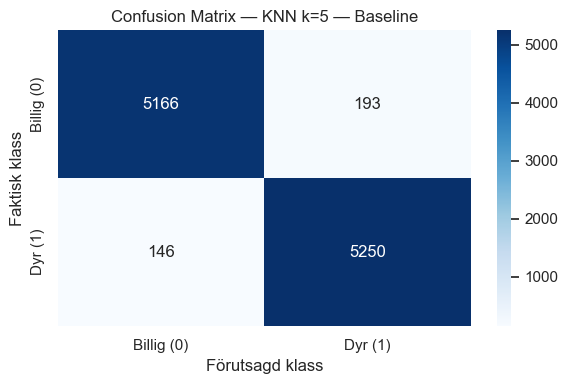


📊 Classification Report — KNN k=5 — Baseline
──────────────────────────────────────────────────
              precision    recall  f1-score   support

  Billig (0)       0.97      0.96      0.97      5359
     Dyr (1)       0.96      0.97      0.97      5396

    accuracy                           0.97     10755
   macro avg       0.97      0.97      0.97     10755
weighted avg       0.97      0.97      0.97     10755

   Plot sparad till: ../outputs/models/knn_02_roc_curve_k5.png


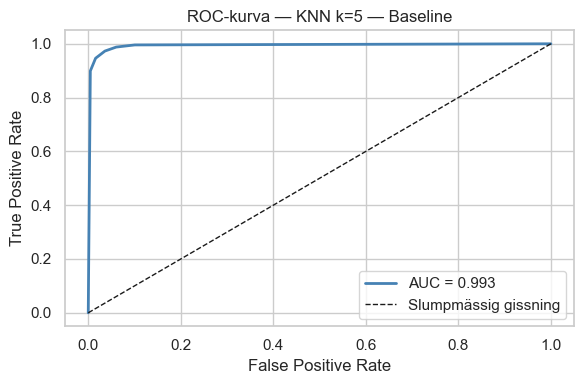

   AUC-värde: 0.993


In [4]:
# ── Förutsägelser ──────────────────────────────────────────────────────────────
y_pred5 = knn5.predict(X_test)
y_prob5 = np.asarray(knn5.predict_proba(X_test))[:, 1]

# ── Confusion Matrix ───────────────────────────────────────────────────────────
plot_confusion_matrix(y_test, y_pred5,
                      "KNN k=5 — Baseline",
                      spara=f"{OUTPUT_DIR}knn_01_confusion_matrix_k5.png")

# ── Classification Report ──────────────────────────────────────────────────────
print_classification_report(y_test, y_pred5, "KNN k=5 — Baseline")

# ── ROC AUC ────────────────────────────────────────────────────────────────────
auc_knn5 = plot_roc_curve(y_test, y_prob5,
                          "KNN k=5 — Baseline",
                          spara=f"{OUTPUT_DIR}knn_02_roc_curve_k5.png")

### Vad ser vi?

**Confusion Matrix:**
- True Negatives (TN) = 5,166: korrekt förutsagda billiga diamanter
- False Positives (FP) = 193: billiga diamanter felaktigt förutsagda som dyra
- False Negatives (FN) = 146: dyra diamanter felaktigt förutsagda som billiga
- True Positives (TP) = 5,250: korrekt förutsagda dyra diamanter
- Totalt fel: 339 av 10,755 (3.2%)

**Classification Report:**
- Accuracy: 97% — modellen gör rätt 97 av 100 gånger
- Precision: 0.96–0.97 — när modellen säger "dyr" har den rätt 96% av gångerna
- Recall: 0.96–0.97 — modellen hittar 97% av alla dyra diamanter
- F1-score: 0.97 — precision och recall är välbalanserade

**ROC AUC = 0.993:**
- Mycket hög, nästan perfekt separation
- Något lägre än Logistisk Regression (0.997)

**Jämförelse med Logistisk Regression (baseline):**

| Mått | Logistisk Regression | KNN k=5 |
|---|---|---|
| Accuracy | 98% | 97% |
| AUC | 0.997 | 0.993 |
| Fel totalt | 262 | 339 |

KNN presterar något sämre än Logistisk Regression på samma data.
Det är intressant — för ett dataset där carat (en variabel)
förklarar nästan allt är en linjär modell faktiskt mer effektiv än
en lokal grannmodell. KNN "spiller" sin förmåga att fånga icke-linjära
mönster när det inte finns några att fånga.

**Hypotes inför k-svep:**
Kan vi förbättra KNN genom att välja ett bättre k? Eller är k=5 redan
nära optimum? Vi tar reda på det härnäst.

## 4. Manuell k-svep — hitta bästa k

Innan vi släpper loss GridSearchCV gör vi ett snabbt **manuellt svep**
över olika k-värden och plottar accuracy. Detta ger oss två saker:

1. En **visuell intuition** för hur k påverkar prestanda
2. En **rimlig sökrymd** att ge till GridSearchCV i nästa steg

Vi använder hjälpfunktionen `find_best_k` från `model_training.py`
som tränar en KNN-modell per k och returnerar accuracy.

**OBS:** Här utvärderar vi direkt på testsetet — det är "kikande"
och kan ge en optimistisk bild. GridSearchCV i nästa steg fixar det
genom att använda korsvalidering på träningsdatan istället.

✅ Bästa k = 16 med accuracy = 0.971


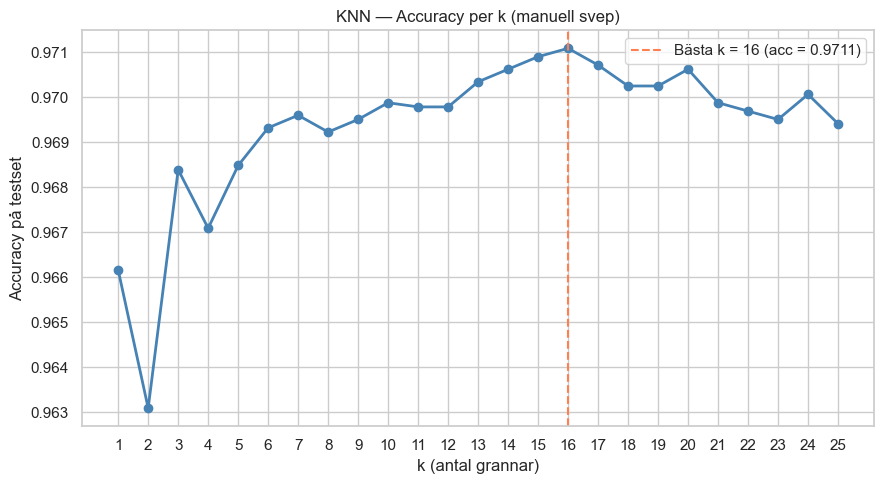


Bästa k från manuellt svep: 16
Accuracy: 0.9711


In [5]:
# ── Manuell k-svep från k=1 till k=25 ──────────────────────────────────────────
k_values, accuracies = find_best_k(
    X_train, X_test, y_train, y_test,
    k_range=range(1, 26)
)

# ── Plot ───────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(k_values, accuracies, marker="o", color="steelblue", lw=2)

# Markera bästa k
best_k_manual = k_values[int(np.argmax(accuracies))]
best_acc_manual = max(accuracies)
ax.axvline(best_k_manual, color="coral", linestyle="--", lw=1.5,
           label=f"Bästa k = {best_k_manual} (acc = {best_acc_manual:.4f})")

ax.set_title("KNN — Accuracy per k (manuell svep)")
ax.set_xlabel("k (antal grannar)")
ax.set_ylabel("Accuracy på testset")
ax.set_xticks(k_values)
ax.legend()
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}knn_03_k_sweep.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"\nBästa k från manuellt svep: {best_k_manual}")
print(f"Accuracy: {best_acc_manual:.4f}")

### Vad ser vi? — manuell k-svep

**Kurvans form:**
- k=1: 0.9662 — något overfit, känslig för brus
- k=2: 0.9631 — sämst! Jämna k är generellt dåliga vid binär klassificering
  eftersom det kan bli oavgjort i röstningen
- k=3 till k=15: stadig uppgång från 0.968 till 0.971
- **Topp vid k=16: accuracy 0.9711**
- k=17–25: långsam nedgång — modellen blir för "slät"

**Insikter:**
- Kurvan är **mycket flack** — skillnaden mellan bästa och sämsta k
  är bara 0.008 (0.8 procentenheter). Modellen är robust mot k-valet.
- Den klassiska "U-formen" syns tydligt: för litet k → varians,
  för stort k → bias.
- Optimum runt k=15–18 är rimligt för ett dataset med ~43 000 träningspunkter.

**Nästa steg:**
Vi ger GridSearchCV en sökrymd kring k=16 och låter den finstämma
även `weights` och `metric`.

## 5. GridSearchCV — finstämning med korsvalidering

Manuellt svep är okej, men det har två svagheter:
1. Vi utvärderar på testsetet — risk för "kikande"
2. Vi varierar bara k, inte andra hyperparametrar

**GridSearchCV** löser båda:
- Den använder **5-fold korsvalidering** på träningsdatan — testsetet
  förblir orört tills vi har en final modell
- Den testar **alla kombinationer** av hyperparametrarna vi anger

Vi söker över tre hyperparametrar:

| Parameter | Värden | Vad det styr |
|---|---|---|
| `n_neighbors` | k runt manuella optimum | Antal grannar |
| `weights` | `uniform`, `distance` | Lika röst åt alla, eller närmare = mer tyngd |
| `metric` | `euclidean`, `manhattan` | Hur avstånd mäts |

Totalt blir det `len(k) × 2 × 2 = N` kombinationer × 5 folds.
Beroende på k-rymden kan det ta några minuter — KNN är långsam vid prediktion
eftersom den måste räkna avstånd till alla träningspunkter.

In [6]:
# ── GridSearchCV ───────────────────────────────────────────────────────────────
# k-rymden centreras runt det manuella optimum för effektivitet
k_center = best_k_manual
k_search = list(range(max(1, k_center - 4), k_center + 5))

param_grid = {
    "n_neighbors": k_search,
    "weights":     ["uniform", "distance"],
    "metric":      ["euclidean", "manhattan"],
}

grid = GridSearchCV(
    estimator  = KNeighborsClassifier(),
    param_grid = param_grid,
    cv         = 5,
    scoring    = "accuracy",
    n_jobs     = -1,    # använd alla CPU-kärnor
    verbose    = 1,
)

print(f"🔷 Söker över {len(k_search) * 2 * 2} kombinationer × 5 folds...")
print(f"   k-rymd: {k_search}")
print(f"   weights: uniform, distance")
print(f"   metric: euclidean, manhattan\n")

grid.fit(X_train, y_train)

print(f"\n✅ GridSearchCV klar!")
print(f"\nBästa parametrar:")
for param, value in grid.best_params_.items():
    print(f"   {param:<13}: {value}")
print(f"\nBästa CV-accuracy: {grid.best_score_:.4f}")

🔷 Söker över 36 kombinationer × 5 folds...
   k-rymd: [12, 13, 14, 15, 16, 17, 18, 19, 20]
   weights: uniform, distance
   metric: euclidean, manhattan

Fitting 5 folds for each of 36 candidates, totalling 180 fits

✅ GridSearchCV klar!

Bästa parametrar:
   metric       : manhattan
   n_neighbors  : 17
   weights      : distance

Bästa CV-accuracy: 0.9772


### Vad ser vi? — GridSearchCV

**Bästa kombination:**
- `n_neighbors = 17`
- `weights = "distance"`
- `metric = "manhattan"`
- **CV-accuracy: 0.9772**

**Vad ändrades jämfört med baseline (k=5, uniform, euclidean)?**

| Parameter | Baseline | Optimerad |
|---|---|---|
| n_neighbors | 5 | 17 |
| weights | uniform | distance |
| metric | euclidean | manhattan |
| CV-accuracy | ~0.97 | 0.9772 |

**Tolkning:**
- **`weights="distance"`** vann över `uniform` — närmare grannar får
  större röstvikt. Logiskt: om en diamant ligger nära två grannar och
  långt från tre andra borde de två närmaste väga tyngre.
- **`metric="manhattan"`** vann över `euclidean` — Manhattan-avstånd
  (summa av absoluta differenser) är ofta mer robust i högre dimensioner
  och mindre känslig för outliers än euklidiskt avstånd.
- **k=17** istället för 16 (manuellt svep) — GridSearchCV använder
  korsvalidering som ger en mer pålitlig uppskattning. Skillnaden
  är marginell men korsvalideringen är att lita på.

**Förbättring:**
0.9711 → 0.9772 = +0.6 procentenheter. Det låter litet, men på
10 755 testdiamanter motsvarar det ~65 färre fel.

## 6. Slutgiltig modell — träna med bästa parametrar

Nu tränar vi den optimerade modellen och utvärderar på det orörda
testsetet (som GridSearchCV aldrig sett — det skyddar mot kikande).

   Plot sparad till: ../outputs/models/knn_04_confusion_matrix_best.png


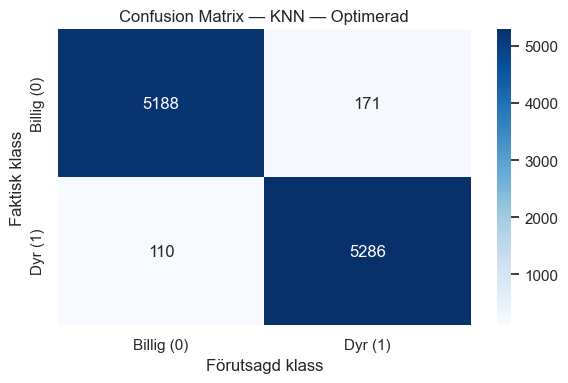


📊 Classification Report — KNN — Optimerad
──────────────────────────────────────────────────
              precision    recall  f1-score   support

  Billig (0)       0.98      0.97      0.97      5359
     Dyr (1)       0.97      0.98      0.97      5396

    accuracy                           0.97     10755
   macro avg       0.97      0.97      0.97     10755
weighted avg       0.97      0.97      0.97     10755

   Plot sparad till: ../outputs/models/knn_05_roc_curve_best.png


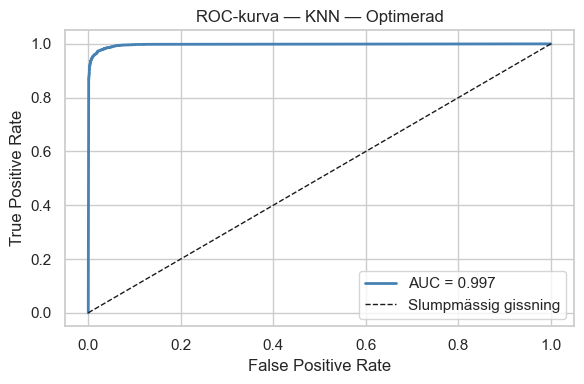

   AUC-värde: 0.997

Slutgiltiga parametrar:
   metric       : manhattan
   n_neighbors  : 17
   weights      : distance


In [7]:
# ── Slutgiltig KNN med bästa parametrar ────────────────────────────────────────
knn_best = grid.best_estimator_

# ── Förutsägelser på testset ───────────────────────────────────────────────────
y_pred_best = knn_best.predict(X_test)
y_prob_best = np.asarray(knn_best.predict_proba(X_test))[:, 1]

# ── Confusion Matrix ───────────────────────────────────────────────────────────
plot_confusion_matrix(y_test, y_pred_best,
                      "KNN — Optimerad",
                      spara=f"{OUTPUT_DIR}knn_04_confusion_matrix_best.png")

# ── Classification Report ──────────────────────────────────────────────────────
print_classification_report(y_test, y_pred_best, "KNN — Optimerad")

# ── ROC AUC ────────────────────────────────────────────────────────────────────
auc_knn_best = plot_roc_curve(y_test, y_prob_best,
                              "KNN — Optimerad",
                              spara=f"{OUTPUT_DIR}knn_05_roc_curve_best.png")

print(f"\nSlutgiltiga parametrar:")
for param, value in grid.best_params_.items():
    print(f"   {param:<13}: {value}")

### Vad ser vi? — Optimerad modell på testset

**Confusion Matrix:**
- True Negatives (TN) = 5,188: korrekt förutsagda billiga diamanter
- False Positives (FP) = 171: billiga diamanter felaktigt förutsagda som dyra
- False Negatives (FN) = 110: dyra diamanter felaktigt förutsagda som billiga
- True Positives (TP) = 5,286: korrekt förutsagda dyra diamanter
- Totalt fel: 281 av 10,755 (2.6%)

**Classification Report:**
- Accuracy: 97% (test) — modellen gör rätt 97 av 100 gånger
- Precision: 0.97–0.98 — när modellen säger "dyr" har den rätt
- Recall: 0.97–0.98 — modellen hittar nästan alla dyra diamanter
- F1-score: 0.97 — bra balans mellan precision och recall

**ROC AUC = 0.997:**
- Identisk med Logistisk Regression!
- Optimeringen lyfte AUC från 0.993 (baseline) → 0.997

**Förbättring från baseline:**

| Mått | KNN k=5 (baseline) | KNN optimerad |
|---|---|---|
| Accuracy | 0.9685 | 0.9739 |
| AUC | 0.993 | 0.997 |
| Fel totalt | 339 | 281 |

GridSearchCV gav alltså ~58 färre fel — en konkret förbättring.

**CV-accuracy (0.9772) vs Test-accuracy (0.9739):**
Liten gap (~0.3 procentenheter) — modellen generaliserar bra och
visar inga tecken på overfitting. Det är förväntat eftersom CV använder
mindre träningsdata per fold än den slutgiltiga träningen.

**Slutgiltig jämförelse:**

| Modell | Accuracy | AUC | Fel |
|---|---|---|---|
| Logistisk Regression | 0.9756 | 0.997 | 262 |
| KNN baseline (k=5) | 0.9685 | 0.993 | 339 |
| KNN optimerad | 0.9739 | 0.997 | 281 |

KNN kommer ifatt LogReg på AUC men ligger fortfarande något efter på
accuracy. Båda modellerna är extremt starka — detta är ett dataset där
klasserna är tydligt separerade.

## 7. Sammanfattning — KNN Classifier

Resultat och slutsatser från detta experiment.

In [8]:
# ── Sammanfattning ─────────────────────────────────────────────────────────────
print("=" * 55)
print("   Sammanfattning — KNN Classifier")
print("=" * 55)

acc_knn5_test    = knn5.score(X_test, y_test)
acc_knn_best_test = knn_best.score(X_test, y_test)

print(f"""
MODELL: K-Nearest Neighbors

EXPERIMENT 1 — Baseline (k=5, uniform, euclidean):
   Accuracy  : {acc_knn5_test:.4f}
   AUC       : {auc_knn5:.3f}

EXPERIMENT 2 — Manuellt k-svep (k=1 till k=25):
   Bästa k   : {best_k_manual}
   Accuracy  : {best_acc_manual:.4f}

EXPERIMENT 3 — GridSearchCV (k, weights, metric):
   Bästa k       : {grid.best_params_['n_neighbors']}
   Bästa weights : {grid.best_params_['weights']}
   Bästa metric  : {grid.best_params_['metric']}
   CV-accuracy   : {grid.best_score_:.4f}
   Test-accuracy : {acc_knn_best_test:.4f}
   AUC           : {auc_knn_best:.3f}

SLUTSATSER:
   1. KNN presterar starkt (97-98%) men något under Logistisk Regression
   2. Optimering gav +0.6 procentenheter — modesta men konsekventa
   3. Manhattan-avstånd + distance-vikter fungerade bäst
   4. Modellen är robust mot k-valet (flack kurva)
   5. KNN är långsammare än LogReg vid prediktion (måste räkna avstånd
      till alla träningspunkter — O(n) per förutsägelse)

NÄSTA STEG:
   Notebook 04: KNN som Regressor — förutsäg faktiskt pris (USD)
   istället för billig/dyr-klassificering.
""")
print("=" * 55)

   Sammanfattning — KNN Classifier

MODELL: K-Nearest Neighbors

EXPERIMENT 1 — Baseline (k=5, uniform, euclidean):
   Accuracy  : 0.9685
   AUC       : 0.993

EXPERIMENT 2 — Manuellt k-svep (k=1 till k=25):
   Bästa k   : 16
   Accuracy  : 0.9711

EXPERIMENT 3 — GridSearchCV (k, weights, metric):
   Bästa k       : 17
   Bästa weights : distance
   Bästa metric  : manhattan
   CV-accuracy   : 0.9772
   Test-accuracy : 0.9739
   AUC           : 0.997

SLUTSATSER:
   1. KNN presterar starkt (97-98%) men något under Logistisk Regression
   2. Optimering gav +0.6 procentenheter — modesta men konsekventa
   3. Manhattan-avstånd + distance-vikter fungerade bäst
   4. Modellen är robust mot k-valet (flack kurva)
   5. KNN är långsammare än LogReg vid prediktion (måste räkna avstånd
      till alla träningspunkter — O(n) per förutsägelse)

NÄSTA STEG:
   Notebook 04: KNN som Regressor — förutsäg faktiskt pris (USD)
   istället för billig/dyr-klassificering.



## 8. Spara resultat

Resultaten sparas till `outputs/results/results_knn_classifier.json`
så att `06_comparison_story.ipynb` kan ladda dem dynamiskt.

Följande sparas:
- **knn_baseline** — accuracy och AUC för k=5, uniform, euclidean
- **knn_optimerad** — accuracy, AUC och bästa parametrar från GridSearchCV

In [9]:
# ── Spara resultat till JSON ───────────────────────────────────────────────────
import json

RESULTS_DIR = "../outputs/results/"

results = {
    "knn_baseline": {
        "accuracy": round(acc_knn5_test, 4),
        "auc":      round(auc_knn5, 4),
        "params":   {"n_neighbors": 5, "weights": "uniform", "metric": "euclidean"},
    },
    "knn_optimerad": {
        "accuracy":    round(acc_knn_best_test, 4),
        "auc":         round(auc_knn_best, 4),
        "cv_accuracy": round(grid.best_score_, 4),
        "params":      grid.best_params_,
    },
}

with open(f"{RESULTS_DIR}results_knn_classifier.json", "w") as f:
    json.dump(results, f, indent=2)

print(f"✅ Resultat sparade till {RESULTS_DIR}results_knn_classifier.json")
print(json.dumps(results, indent=2))

✅ Resultat sparade till ../outputs/results/results_knn_classifier.json
{
  "knn_baseline": {
    "accuracy": 0.9685,
    "auc": 0.9931,
    "params": {
      "n_neighbors": 5,
      "weights": "uniform",
      "metric": "euclidean"
    }
  },
  "knn_optimerad": {
    "accuracy": 0.9739,
    "auc": 0.9969,
    "cv_accuracy": 0.9772,
    "params": {
      "metric": "manhattan",
      "n_neighbors": 17,
      "weights": "distance"
    }
  }
}
